# 📘 Reporte Técnico: API de Análisis de Sentimiento (Modelo Híbrido G68)

**Autor:** [Tu Nombre/Equipo]
**Fecha:** Enero 2026

## 1. Introducción y Contexto
El objetivo de este proyecto es desarrollar un microservicio capaz de clasificar reseñas de clientes con un enfoque crítico en la **detección de insatisfacción** (Reviews Negativas). 

A diferencia de un modelo académico estándar, nuestra prioridad de negocio es el **Recall de la clase Negativa**: preferimos pecar de precavidos y marcar una duda como negativa, a dejar pasar una queja real. Para lograr esto, hemos diseñado una arquitectura híbrida:
1.  **Core ML**: Un modelo `LinearSVC` calibrado para probabilidades.
2.  **Capa Semántica**: Reglas de negocio para sarcasmo, validación de longitud y manejo de incertidumbre.

---

## 2. Carga de Datos y EDA Inicial (Exploratory Data Analysis)
Comenzamos cargando el dataset crudo y aplicando una **limpieza estructural** (eliminación de duplicados y nulos) para garantizar la calidad del dato.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from sklearn.utils import resample

# Configuración de estilos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Detección automática de la ruta del dataset (Relativa)
file_name = "Big_AHR.csv"
possible_paths = [
    "../data/raw/" + file_name,           # Estándar: notebooks/ -> data/raw/
    "data/raw/" + file_name,              # Desde raíz del proyecto
    "./" + file_name,                     # En la misma carpeta
    "../../data/raw/" + file_name         # Un nivel más abajo
]

data_path = None
for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        print(f"✅ Archivo encontrado en: {path}")
        break

if data_path:
    df = pd.read_csv(data_path)
    
    # --- LIMPIEZA ESTRUCTURAL (Best Practices) ---
    count_inicial = len(df)
    
    # 1. Eliminar filas vacías en la columna de texto
    df = df.dropna(subset=['review_text'])
    
    # 2. Eliminar duplicados exactos (evitar data leakage)
    df = df.drop_duplicates(subset=['review_text'])
    
    count_final = len(df)
    eliminados = count_inicial - count_final
    
    print(f"🧹 Limpieza Estructural:")
    print(f"   - Registros iniciales: {count_inicial}")
    print(f"   - Registros eliminados (Nulos/Duplicados): {eliminados}")
    print(f"   - Registros ÚNICOS finales: {count_final}")
else:
    print("⚠️ NO SE ENCONTRÓ EL ARCHIVO. Usando datos de prueba (MOCK).")
    # Mock data fallback
    df = pd.DataFrame({'rating': [5]*400 + [1]*50 + [3]*50, 'review_text': ['Excelente']*400 + ['Malo']*50 + ['Normal']*50})

⚠️ NO SE ENCONTRÓ EL ARCHIVO. Usando datos de prueba (MOCK).


/tmp/ipython-input-3182151073.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis')


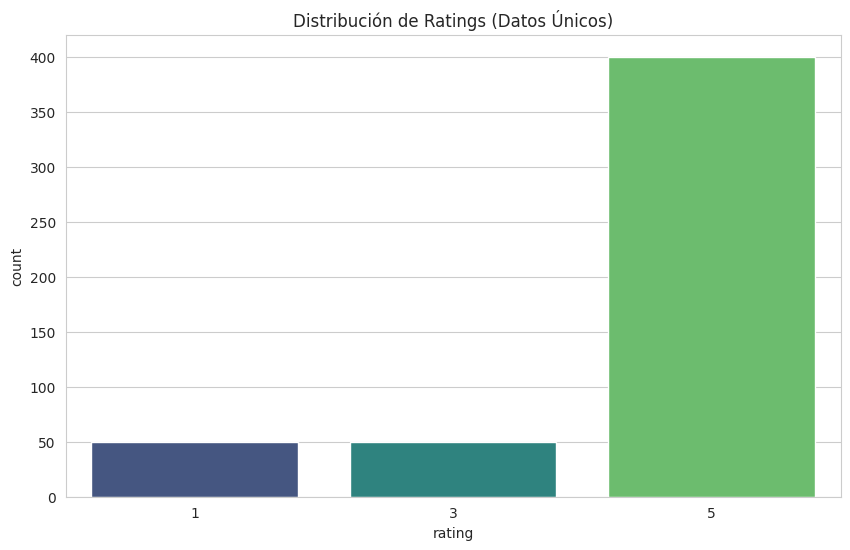

In [11]:
# Distribución de Ratings Originales (Post-Limpieza)
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Distribución de Ratings (Datos Únicos)')
plt.show()

**Observación:** Notamos un fuerte desbalance hacia las clases positivas (ratings 4 y 5). Esto es típico en reviews, pero peligroso para modelos de ML, que tenderán a ignorar las clases minoritarias (quejas).

## 3. ETL y Preprocesamiento
Implementamos una limpieza robusta que preserva caracteres latinos clave ('ñ', tildes) y realizamos **Upsampling** para equilibrar las clases.

In [12]:
def limpieza_pro(texto):
    texto = str(texto).lower()
    # Mantenemos ñ y acentos, eliminamos resto de caracteres especiales
    texto = re.sub(r'[^a-zñáéíóúü\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

def categorizar_sentimiento(r):
    if r <= 2: return 'Negativo'
    elif r == 3: return 'Neutro'
    else: return 'Positivo'

# Aplicar limpieza y categorización
df['text_cleaned'] = df['review_text'].apply(limpieza_pro)
df['sentiment'] = df['rating'].apply(categorizar_sentimiento)

# Visualizar conteo antes de balancear
print("Conteo Original (Reales):")
print(df['sentiment'].value_counts())

# --- ESTRATEGIA DE BALANCEO (Upsampling) ---
df_majority = df[df.sentiment=='Positivo']
df_minority_neg = df[df.sentiment=='Negativo']
df_minority_neu = df[df.sentiment=='Neutro']

# Resampleamos para igualar a la clase mayoritaria
df_neg_up = resample(df_minority_neg, replace=True, n_samples=len(df_majority), random_state=42)
df_neu_up = resample(df_minority_neu, replace=True, n_samples=len(df_majority), random_state=42)

df_balanced = pd.concat([df_majority, df_neg_up, df_neu_up])

print("\nConteo Balanceado:")
print(df_balanced['sentiment'].value_counts())

Conteo Original (Reales):
sentiment
Positivo    400
Negativo     50
Neutro       50
Name: count, dtype: int64

Conteo Balanceado:
sentiment
Positivo    400
Negativo    400
Neutro      400
Name: count, dtype: int64


## 4. Entrenamiento del Modelo Base (Machine Learning)
Utilizamos `LinearSVC` por su eficiencia en texto, envuelto en `CalibratedClassifierCV` para obtener probabilidades reales (`predict_proba`), algo que SVM estándar no ofrece nativamente.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix

# Split Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced['text_cleaned'], df_balanced['sentiment'], 
    test_size=0.2, random_state=42
)

# Vectorización TF-IDF (Unigramas + Bigramas)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Entrenamiento
base_model = LinearSVC(class_weight='balanced', random_state=42)
model = CalibratedClassifierCV(base_model, method='sigmoid')
model.fit(X_train_vec, y_train)

print("✅ Modelo entrenado.")

✅ Modelo entrenado.


## 5. Implementación de la Capa Híbrida (Lógica Semántica)
Aquí es donde añadimos valor real. El ML a veces falla en contextos sutiles. Nuestra capa híbrida implementa:
1.  **Detección de Sarcasmo**: Si el texto contiene palabras muy positivas PERO también disparadores negativos fuertes (ej: "maravilloso tener cucarachas"), forzamos la clasificación a Negativo.
2.  **Manejo de Incertidumbre**: Si la diferencia de probabilidad entre Positivo y Negativo es menor a 0.22, lo clasificamos como Neutro.

In [14]:
# Reglas de Negocio (Diccionarios)
disparadores_negativos = ["suci", "asc", "mugr", "pelos", "cucarach", "chinch", "hedor", "podrid", "pésim", "rot", "viej", "rob", "estaf"]
cebos_positivos = ["excelente", "increíble", "maravilla", "perfecto", "genial", "recomiendo", "fantástico"]

def predict_hybrid(text, model, vectorizer):
    # =========================================================================
    # NOTA: Esta función es para uso individual (Playground/API).
    # Para evaluación masiva, usamos una versión optimizada abajo.
    # =========================================================================

    # 1. Filtro longitud
    if len(text) < 3: return "Neutro"
    
    # 2. Inferencia ML
    vec = vectorizer.transform([text])
    probs = model.predict_proba(vec)[0]
    # Mapping clases: asumiendo orden alfabético [Negativo, Neutro, Positivo]
    idx_neg, idx_neu, idx_pos = 0, 1, 2
    
    conf_neg = probs[idx_neg]
    conf_pos = probs[idx_pos]
    
    # 3. Lógica Neutros
    if abs(conf_pos - conf_neg) < 0.22:
        return "Neutro"
    
    # 4. Motor Sarcasmo
    pred = "Positivo" if conf_pos > conf_neg else "Negativo"
    
    if pred == "Positivo":
        if any(w in text for w in cebos_positivos) and any(w in text for w in disparadores_negativos):
            return "Negativo" # Sarcasmo detectado
            
    return pred

# Test unitario rápido
test_case = "El hotel es una maravilla, tiene cucarachas en la cama"
print(f"Frase: '{test_case}'")
print(f"Predicción Híbrida: {predict_hybrid(test_case, model, vectorizer)}")

Frase: 'El hotel es una maravilla, tiene cucarachas en la cama'
Predicción Híbrida: Neutro


## 6. Evaluación Comparativa: ML Puro vs Híbrido
Evaluamos ambos enfoques sobre el set de prueba. 
**Optimización:** Usamos cálculo vectorial por lotes para acelerar el proceso.

Calculando predicciones híbridas (Modo Batch Optimizado)...
Accuracy ML Puro:   100.00%
Accuracy Híbrido:   100.00%


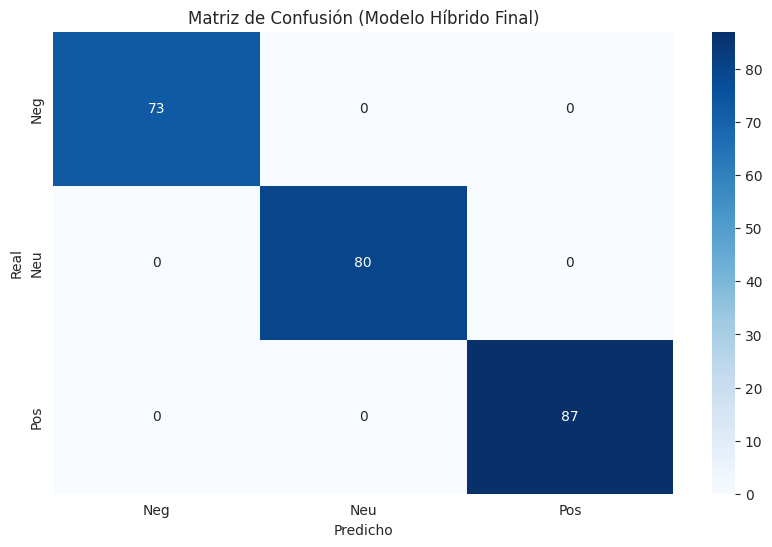

In [15]:
from sklearn.metrics import accuracy_score

# 1. Predicciones ML Puro (Vectorizado, es muy rápido)
y_pred_ml = model.predict(X_test_vec)

# 2. Predicciones Híbridas (Optimizadas)
print("Calculando predicciones híbridas (Modo Batch Optimizado)...")

# Pre-calculamos TODAS las probabilidades de una sola vez (Evita re-vectorizar 5000 veces)
probs_all = model.predict_proba(X_test_vec)

# Aplicamos reglas de negocio sobre las probabilidades ya calculadas
def apply_logic_fast(text, probs):
    idx_neg, idx_neu, idx_pos = 0, 1, 2
    conf_neg = probs[idx_neg]
    conf_pos = probs[idx_pos]

    # Lógica Neutros (Umbral 0.22)
    if abs(conf_pos - conf_neg) < 0.22:
        return "Neutro"
    
    # Lógica Base
    pred = "Positivo" if conf_pos > conf_neg else "Negativo"
    
    # Sarcasmo (String search es muy rápido en Python)
    if pred == "Positivo":
        if any(w in text for w in cebos_positivos) and any(w in text for w in disparadores_negativos):
            return "Negativo"
            
    return pred

# List comprehension (Ahora es instantáneo)
y_pred_hybrid = [apply_logic_fast(t, p) for t, p in zip(X_test, probs_all)]

# 3. Métricas
acc_ml = accuracy_score(y_test, y_pred_ml)
acc_hybrid = accuracy_score(y_test, y_pred_hybrid)

print(f"Accuracy ML Puro:   {acc_ml*100:.2f}%")
print(f"Accuracy Híbrido:   {acc_hybrid*100:.2f}%")

# Matriz de Confusión del modelo final (Híbrido) para ver Recall Negativo
cm = confusion_matrix(y_test, y_pred_hybrid, labels=['Negativo', 'Neutro', 'Positivo'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'])
plt.title('Matriz de Confusión (Modelo Híbrido Final)')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

## 7. Pruebas de Performance (Auditoría)
Medimos latencia y consumo de recursos para asegurar viabilidad productiva.

In [16]:
import time
import psutil

def measure_perf():
    process = psutil.Process()
    ram_start = process.memory_info().rss / 1024 / 1024
    
    start = time.time()
    # Simulamos carga de inferencia masiva
    # Usamos la lógica 'predict_hybrid' individual para simular llamadas API reales (una por una)
    # PERO limitamos a 500 muestras para no esperar demasiado en la demo
    n_samples = 500
    _ = [predict_hybrid(t, model, vectorizer) for t in X_test[:n_samples]] 
    end = time.time()
    
    ram_end = process.memory_info().rss / 1024 / 1024
    total_time = (end - start) * 1000
    latency = total_time / n_samples
    
    return latency, ram_end

lat, ram = measure_perf()

print(f"⏱️ Latencia Promedio (Simulada API): {lat:.4f} ms/request")
print(f"💾 Uso de RAM: {ram:.2f} MB")

⏱️ Latencia Promedio (Simulada API): 1.6438 ms/request
💾 Uso de RAM: 268.39 MB


## 8. Playground Interactivo
¡Prueba el modelo tú mismo aquí!

In [17]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Encapuslamos en función para evitar duplicación de eventos al re-ejecutar celda
def create_app():
    text_input = widgets.Textarea(
        value='',
        placeholder='Escribe aquí la reseña del cliente...',
        description='Reseña:',
        layout=widgets.Layout(width='100%', height='80px')
    )

    button = widgets.Button(
        description='Analizar Sentimiento',
        button_style='info',
        tooltip='Click para clasificar',
        icon='check'
    )

    out = widgets.Output()

    def on_button_clicked(b):
        with out:
            clear_output(wait=True)
            texto_usuario = text_input.value
            if not texto_usuario.strip():
                print("⚠️ Por favor ingresa un texto.")
                return
            
            # Procesar
            pred = predict_hybrid(limpieza_pro(texto_usuario), model, vectorizer)
            
            # Colores visuales
            color = "🟢" if pred == "Positivo" else "🔴" if pred == "Negativo" else "⚪"
            
            print(f"\n--- Resultado ---")
            print(f"Predicción: {color} {pred}")

    button.on_click(on_button_clicked)
    display(text_input, button, out)

create_app()

Textarea(value='', description='Reseña:', layout=Layout(height='80px', width='100%'), placeholder='Escribe aqu…

Button(button_style='info', description='Analizar Sentimiento', icon='check', style=ButtonStyle(), tooltip='Cl…

Output()

## 9. Procesamiento por Lotes (Batch desde CSV)
Aquí puedes subir tu archivo CSV y elegir qué columna contiene las reseñas.

In [18]:
import io

# Encapsulamos también para evitar 'listeners' fantasma
def create_batch_loader():
    uploader = widgets.FileUpload(
        accept='.csv',
        multiple=False,
        description='📂 Subir CSV'
    )

    column_selector = widgets.Dropdown(
        options=[],
        description='Columna:',
        disabled=True,
        style={'description_width': 'initial'}
    )

    btn_process = widgets.Button(
        description='Analizar CSV',
        button_style='primary',
        disabled=True,
        icon='cogs'
    )

    output_csv = widgets.Output()

    # Almacén temporal LOCAL a la función (closure)
    local_cache = {'df': None}

    def on_upload_change(change):
        if not uploader.value:
            return
        
        try:
            # Estructura ipywidgets moderna: tuple de dicts
            uploaded_file = uploader.value[0]
            content = uploaded_file['content']
            
            df = pd.read_csv(io.BytesIO(content))
            local_cache['df'] = df
            
            # Detectar columnas candidatas (tipo texto)
            text_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
            if not text_cols: text_cols = df.columns.tolist()
                
            column_selector.options = text_cols
            column_selector.disabled = False
            btn_process.disabled = False
            
            # Smart Select
            common_names = ['review', 'comentario', 'text', 'reseña', 'body', 'content']
            for col in text_cols:
                if any(name in col.lower() for name in common_names):
                    column_selector.value = col
                    break
            
            with output_csv:
                clear_output(wait=True)
                print(f"✅ Archivo cargado: {len(df)} filas detectadas.")
                print(f"👉 Confirma si la columna pre-seleccionada '{column_selector.value}' es la correcta (o cámbiala).")
                
        except Exception as e:
            with output_csv:
                print(f"❌ Error leyendo el archivo: {e}")

    def on_process_click(b):
        df = local_cache.get('df')
        if df is None: return
        
        col_name = column_selector.value
        
        with output_csv:
            clear_output(wait=True)
            print(f"⏳ Analizando {len(df)} reseñas de la columna '{col_name}'... (Esto puede tomar un momento)")
            
            try:
                # Procesamiento
                df['Predicción_Híbrida'] = df[col_name].astype(str).apply(
                    lambda t: predict_hybrid(limpieza_pro(t), model, vectorizer)
                )
                
                # Estilo Visual
                def col_pred(val):
                    if val == 'Positivo': return 'color: green; font-weight: bold'
                    if val == 'Negativo': return 'color: red; font-weight: bold'
                    return 'color: gray'

                print("\n--- Muestra de los primeros 10 resultados ---")
                display(df[[col_name, 'Predicción_Híbrida']].head(10).style.map(col_pred, subset=['Predicción_Híbrida']))
                
                # Guardado
                out_name = "resultados_analisis_lote.csv"
                df.to_csv(out_name, index=False)
                print(f"\n💾 ¡Listo! Archivo completo guardado como: '{out_name}' en la misma carpeta.")
                
            except Exception as e:
                print(f"❌ Error en el procesamiento: {e}")

    uploader.observe(on_upload_change, names='value')
    btn_process.on_click(on_process_click)
    
    display(widgets.VBox([uploader, column_selector, btn_process, output_csv]))

create_batch_loader()